<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E8/fix_E8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Issue #3

In [5]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/deliveries.csv")


In [ ]:
# 3. Sort Data

df = df.sort_values(by=["match_id", "inning", "over", "ball"])

In [11]:
# 4. Initialize Variables

partnerships = []

current_pair = None
current_runs = 0
current_match = None
current_inning = None


In [12]:
# 5. Iterate Row by Row (STATEFUL)
# -----------------------------
for _, row in df.iterrows():

    match_id = row["match_id"]
    inning = row["inning"]
    batsman = row["batter"]
    non_striker = row["non_striker"]
    runs = row["total_runs"]
    wicket = row["is_wicket"]

    pair = tuple(sorted([batsman, non_striker]))  # order-independent

    # New match or inning → reset
    if (match_id != current_match) or (inning != current_inning):
        if current_pair is not None:
            partnerships.append({
                "match_id": current_match,
                "inning": current_inning,
                "pair": current_pair,
                "runs": current_runs
            })

        current_pair = pair
        current_runs = runs
        current_match = match_id
        current_inning = inning

    else:
        # Same pair → continue
        if pair == current_pair:
            current_runs += runs
        else:
            # Pair changed → save old
            partnerships.append({
                "match_id": match_id,
                "inning": inning,
                "pair": current_pair,
                "runs": current_runs
            })

            # Reset for new pair
            current_pair = pair
            current_runs = runs

    # If wicket → end partnership
    if wicket == 1:
        partnerships.append({
            "match_id": match_id,
            "inning": inning,
            "pair": current_pair,
            "runs": current_runs
        })
        current_pair = None
        current_runs = 0


In [13]:
# 6. Convert to DataFrame

partnerships_df = pd.DataFrame(partnerships)

# Remove zero/invalid entries
partnerships_df = partnerships_df[partnerships_df["runs"] > 0]


In [14]:
# 7. Highest Partnership per Match

max_per_match = partnerships_df.loc[
    partnerships_df.groupby("match_id")["runs"].idxmax()
]

print(max_per_match.head())

     match_id  inning                       pair  runs
0      335982       1  (BB McCullum, SC Ganguly)    61
36     335983       1  (MEK Hussey, S Badrinath)    73
65     335984       2      (G Gambhir, S Dhawan)   112
87     335985       2    (JH Kallis, MV Boucher)    55
115    335986       2    (DJ Hussey, SC Ganguly)    47


In [16]:
# 8. Highest Partnership Overall

max_overall = partnerships_df.loc[partnerships_df["runs"].idxmax()]

print("Highest Partnership Overall:")
print(max_overall)

Highest Partnership Overall:
match_id                       980987
inning                              1
pair        (AB de Villiers, V Kohli)
runs                              229
Name: 13733, dtype: object


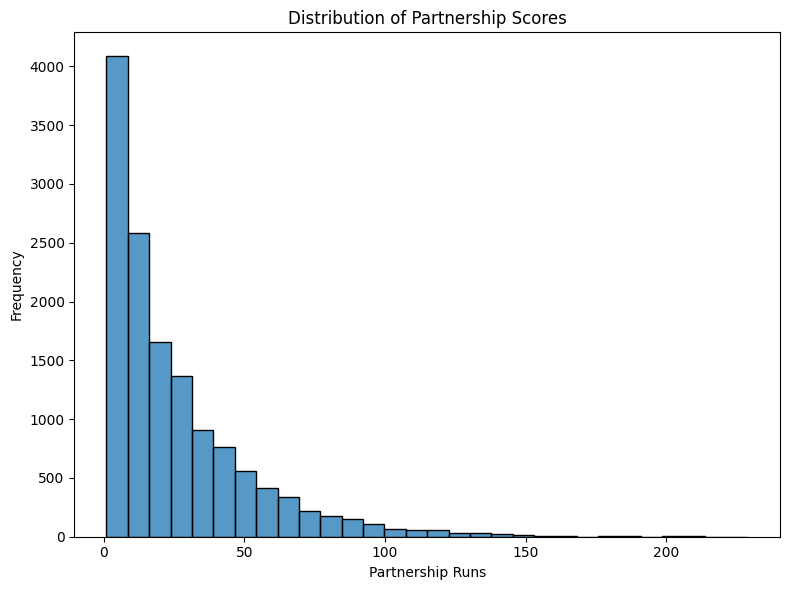

In [18]:
# 9. Visualization (Histogram)

plt.figure(figsize=(8,6))

sns.histplot(partnerships_df["runs"], bins=30)

plt.xlabel("Partnership Runs")
plt.ylabel("Frequency")
plt.title("Distribution of Partnership Scores")

plt.tight_layout()
plt.show()